# Declaration of Originality

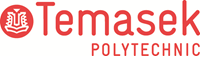

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Kyaw Hsu Thway (2403581H)
* Tutorial Group                : PC03 
* Tutor						    : Ruchir Srivastava 
* Submission Date               : 10.2.2026


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [27]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# 1. Business Understanding
The construction industry relies heavily on concrete as a primary building material, and ensuring that concrete achieves sufficient compressive strength is critical for structural safety, durability, and cost efficiency. Traditionally, determining the compressive strength of concrete requires laboratory testing, which can be time-consuming, resource-intensive, and costly.

The objective of this project is to develop a machine learning model that can predict the compressive strength of concrete (in MPa) based on its material composition and curing age. The dataset includes features such as cement content, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate, and age. By learning the relationship between these input variables and concrete strength, the model can provide accurate strength predictions without the need for extensive physical testing.

This solution can support engineers, contractors, and construction planners in optimizing concrete mix designs, improving quality control, and reducing experimental costs. Ultimately, the model aims to enhance decision-making in construction processes while maintaining safety and performance standards.

# 2. Data Understanding

## 2.1 Load dataset

In [28]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "Concrete_Data.xls"
df = pd.read_excel(FILE_PATH, sheet_name="Sheet1")
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


Firstly, the excel datasheet is read using "read_excel()" function to get a general idea of the dataset. It should be noted that the datasets that has more than one sheet inside has to be used with a parameter sheet_name to specify which exact sheet will be used. At first glance, the dataset looks like it is composed mostly of numerical data but later along the way, I will make sure to check and clean the data more if necessary. It can also be seen that the dataset has total 1030 rows and 9 columns.

## 2.2 Summary Statistics

In [29]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

The code above is used to check the datatypes inside the dataset. It is seen that all of my columns are numerical data. That means it will not be necessary to use one-hot-encoding.

In [30]:
## Check for missing data
df.isna().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

The code above is ran to check if there is any missing data inside the dataset. It is seen that there are no missing data for any columns. Therefore, here again, I will not clean my dataset in this missing data aspect.

In [31]:
## Describe data distribution
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


By using "df.describe()", useful stastical information such as mean, standard deviation, minimum and maximum values can be seen. This dataset contains 1,030 concrete mix samples (show with the "count") with nine numerical features describing material composition, curing age, and resulting compressive strength. The input variables represent quantities of cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, and fine aggregate measured per cubic meter, along with the age of the concrete in days. The target variable is concrete compressive strength (MPa), which ranges from 2.33 to 82.60 MPa, with an average of 35.82 MPa. The dataset shows substantial variability in material proportions and curing age, indicating a diverse set of mix designs suitable for predictive modeling and regression analysis.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

Seeing numerical stastical information can be useful just like it has been done above. However, data make the most sense for developers or anyone trying to use it when it can be visualized. Therefore, we will now visualized our data and see if there is any unbalanced distribution or outliers.

### 2.3.1.1 Understanding distribution of target

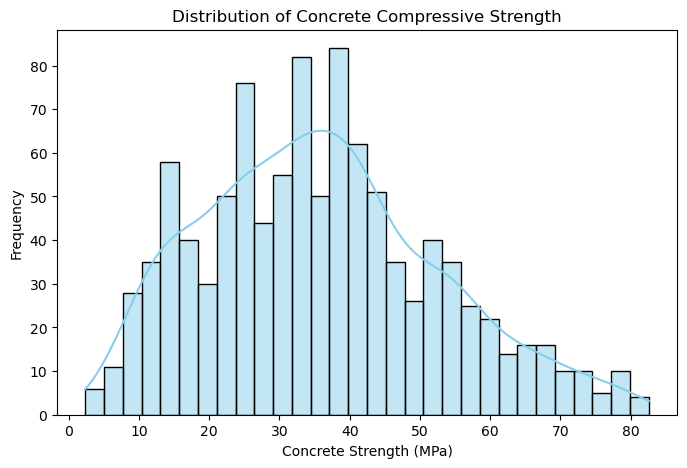

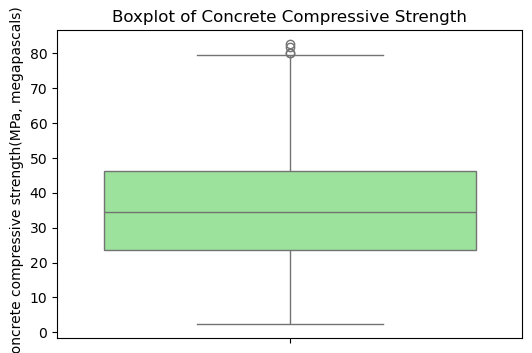

In [32]:
## Understanding distribution of target
# Strip column names first (just in case)
df.columns = df.columns.str.strip()

target_col = 'Concrete compressive strength(MPa, megapascals)'

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df[target_col], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Concrete Compressive Strength')
plt.xlabel('Concrete Strength (MPa)')
plt.ylabel('Frequency')
plt.show()

# Boxplot to check for outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=df[target_col], color='lightgreen')
plt.title('Boxplot of Concrete Compressive Strength')
plt.show()

First, a brief explanation of the code and imports. The code is used for exploratory data analysis (EDA) of the target variable, concrete compressive strength. It uses Pandas to manage the dataset, Matplotlib (plt) for basic plotting, and Seaborn (sns) for more visually appealing statistical plots. The line df.columns = df.columns.str.strip() ensures column names have no leading or trailing spaces, preventing referencing errors. A histogram with a KDE (kernel density estimate) is then plotted to observe the distribution of the target variable, followed by a boxplot to identify spread, central tendency, and potential outliers.

From the histogram, the concrete compressive strength appears to follow a roughly unimodal and slightly right-skewed distribution. Most values cluster between approximately 20 MPa and 50 MPa, with a peak around the mid-30 MPa range. The smooth KDE curve suggests a relatively continuous distribution without sharp irregularities, which is desirable for regression-based machine learning models.

The boxplot shows a median around the mid-30 MPa range, with a moderate interquartile range, indicating reasonable variability in the data. A few high-end outliers are visible above 80 MPa, but they are not extreme and are realistic in real-world concrete strength measurements. The absence of excessive or extreme outliers suggests the data is stable and not heavily skewed by anomalies.

Overall, this target variable is well-suited for training an AI regression model. It has sufficient variability, a smooth distribution, realistic outliers, and no severe imbalance. These characteristics help models learn meaningful patterns and generalize well to unseen data.

### 2.3.1.2 Understanding distribution of features

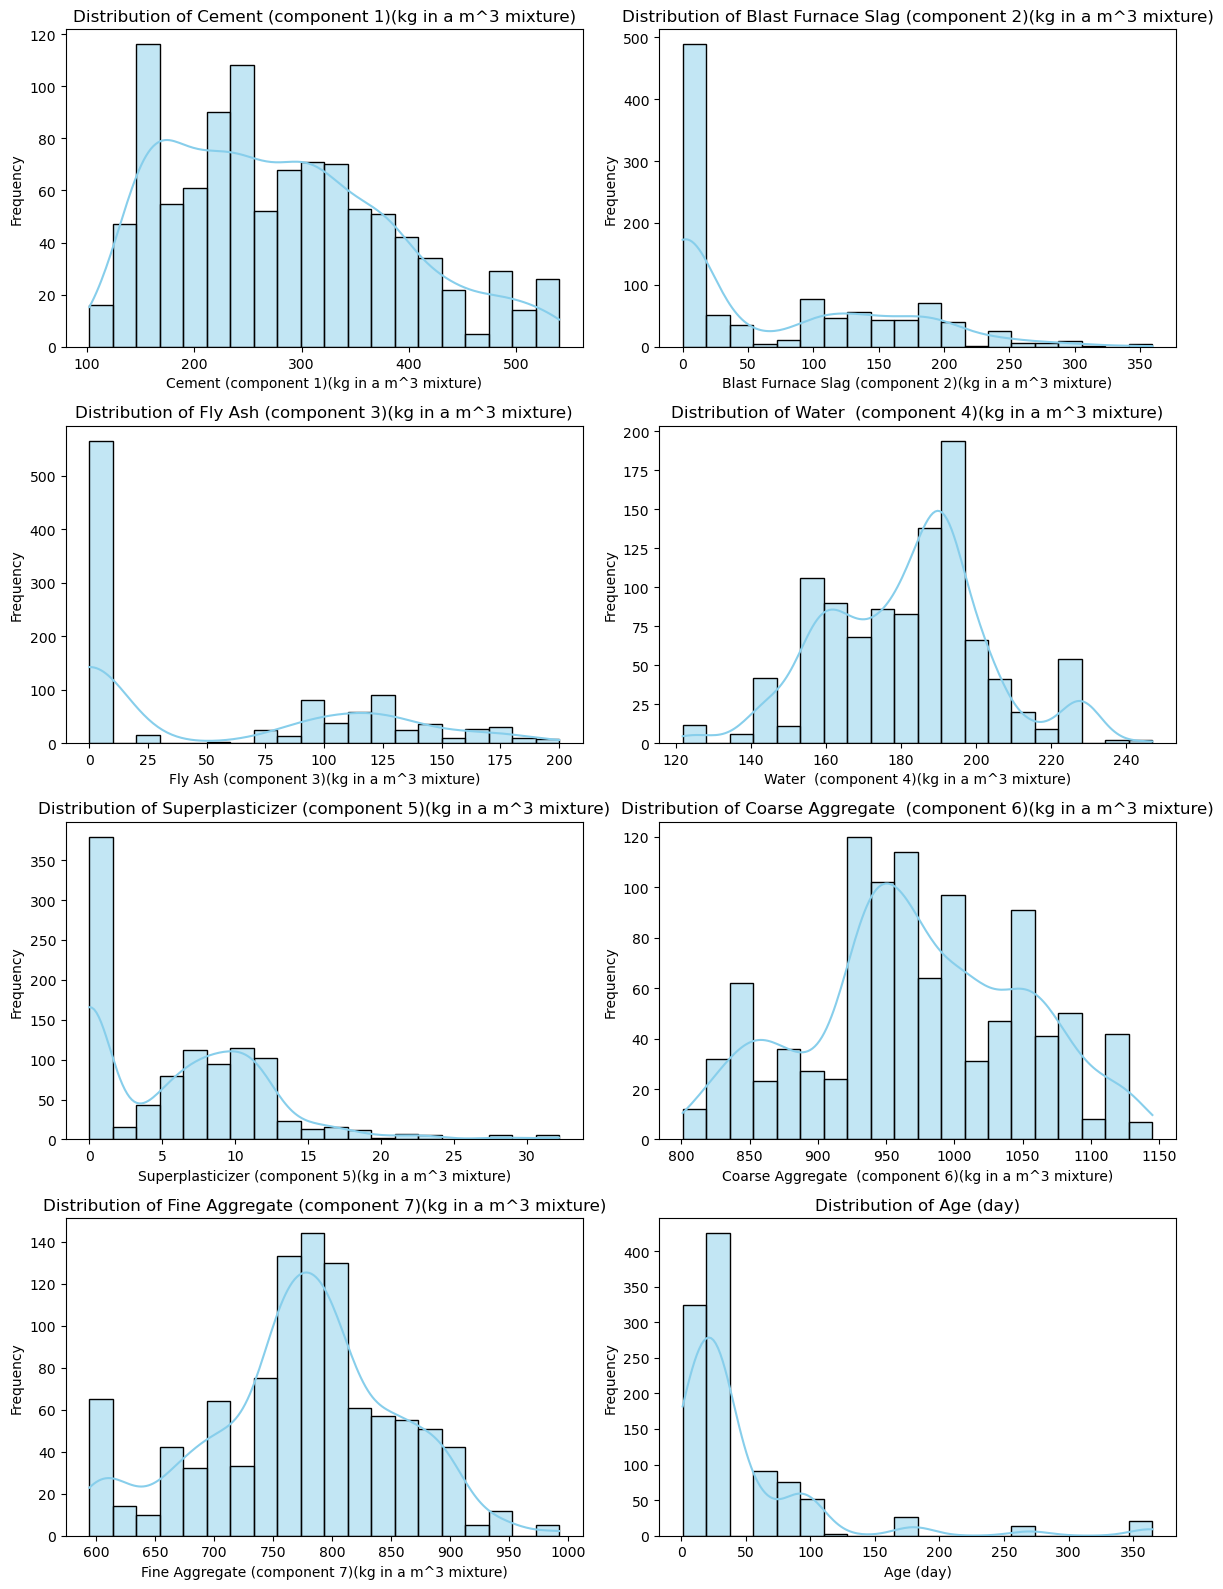

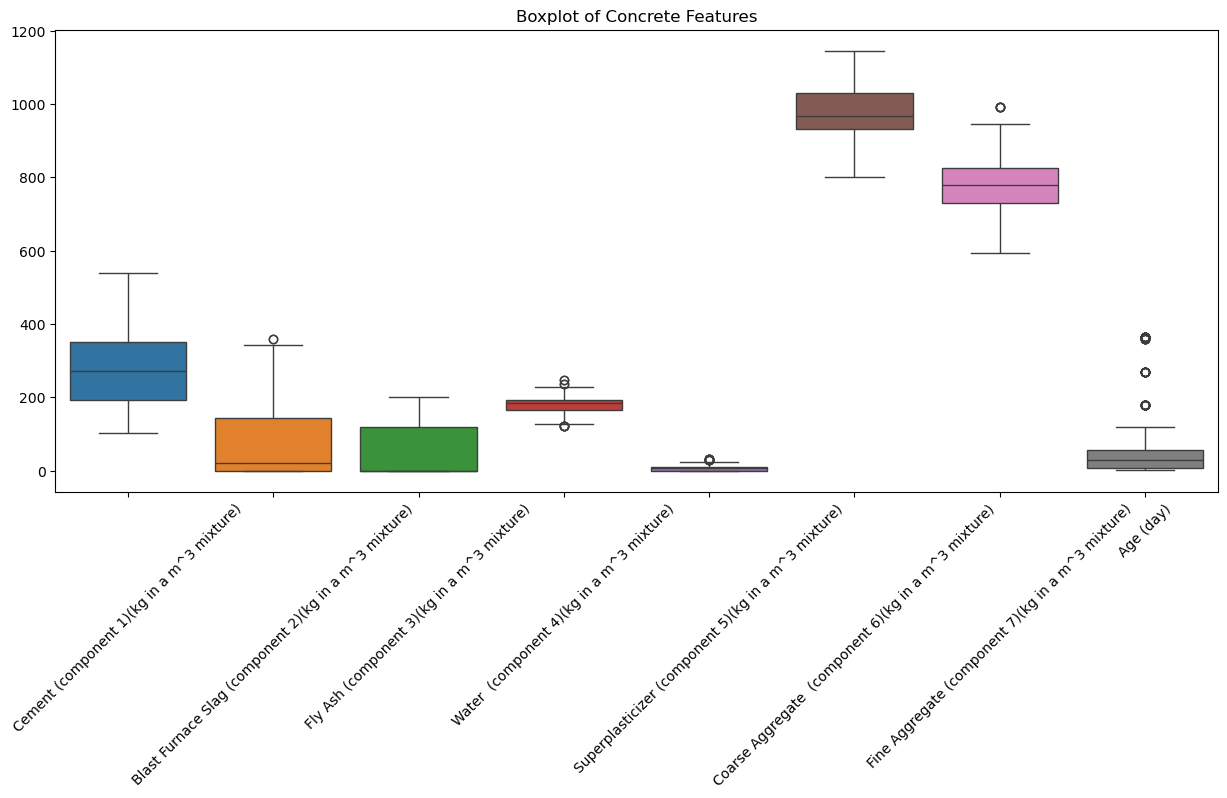

In [33]:
## Understanding distribution of features

# List of feature columns (all except target)
feature_cols = df.drop(columns=[target_col]).columns

# Histograms for each feature
# Feature columns
feature_cols = df.drop(columns=[target_col]).columns

# Define number of columns
n_cols = 2
n_rows = (len(feature_cols) + n_cols - 1) // n_cols  # ceil division

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()  # flatten to 1D array for easy looping

# Plot histograms
for i, col in enumerate(feature_cols):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Optional: Boxplots for all features to check scale & outliers
plt.figure(figsize=(15,6))
sns.boxplot(data=df[feature_cols])
plt.xticks(rotation=45)
plt.title('Boxplot of Concrete Features')
plt.show()


The code performs exploratory data analysis (EDA) on all input features (excluding the target variable). Just like before, Pandas is used to select and manage the feature columns, Matplotlib handles figure layout and rendering, and Seaborn is used to plot histograms with KDE curves and boxplots for better statistical insight. The code dynamically creates a grid of subplots, plots a histogram with a density curve for each feature to examine its distribution, and then generates a combined boxplot to compare feature scales and identify potential outliers across all variables.

From the feature distribution histograms, several patterns are evident. Cement, water, coarse aggregate, and fine aggregate show relatively smooth, unimodal distributions, suggesting consistent usage ranges across samples. In contrast, blast furnace slag, fly ash, and superplasticizer exhibit strong right-skewness with many zero or low values, indicating that these components are optional or used selectively in mix designs. The age feature is also heavily right-skewed, with most samples concentrated at early curing days and fewer long-term measurements, which reflects realistic experimental and industry practices.

The boxplot highlights that features are on very different scales, ranging from single-digit quantities (superplasticizer) to values exceeding 1,000 kg (aggregates). Several outliers are visible, especially for age and supplementary cementitious materials, but these are domain-valid rather than erroneous. This indicates that feature scaling or normalization will be important before model training if just linear regression model is used, but tree-based models like Random Forest or XGBoost don’t usually require scaling. However, no features appear fundamentally problematic.

Overall, the feature distributions are diverse, realistic, and information-rich, making them well-suited for training an AI regression model. The variability across components allows the model to learn meaningful relationships, while the presence of skewed features can be handled effectively using transformations or tree-based models.

### 2.3.2 Understanding relationship between variables

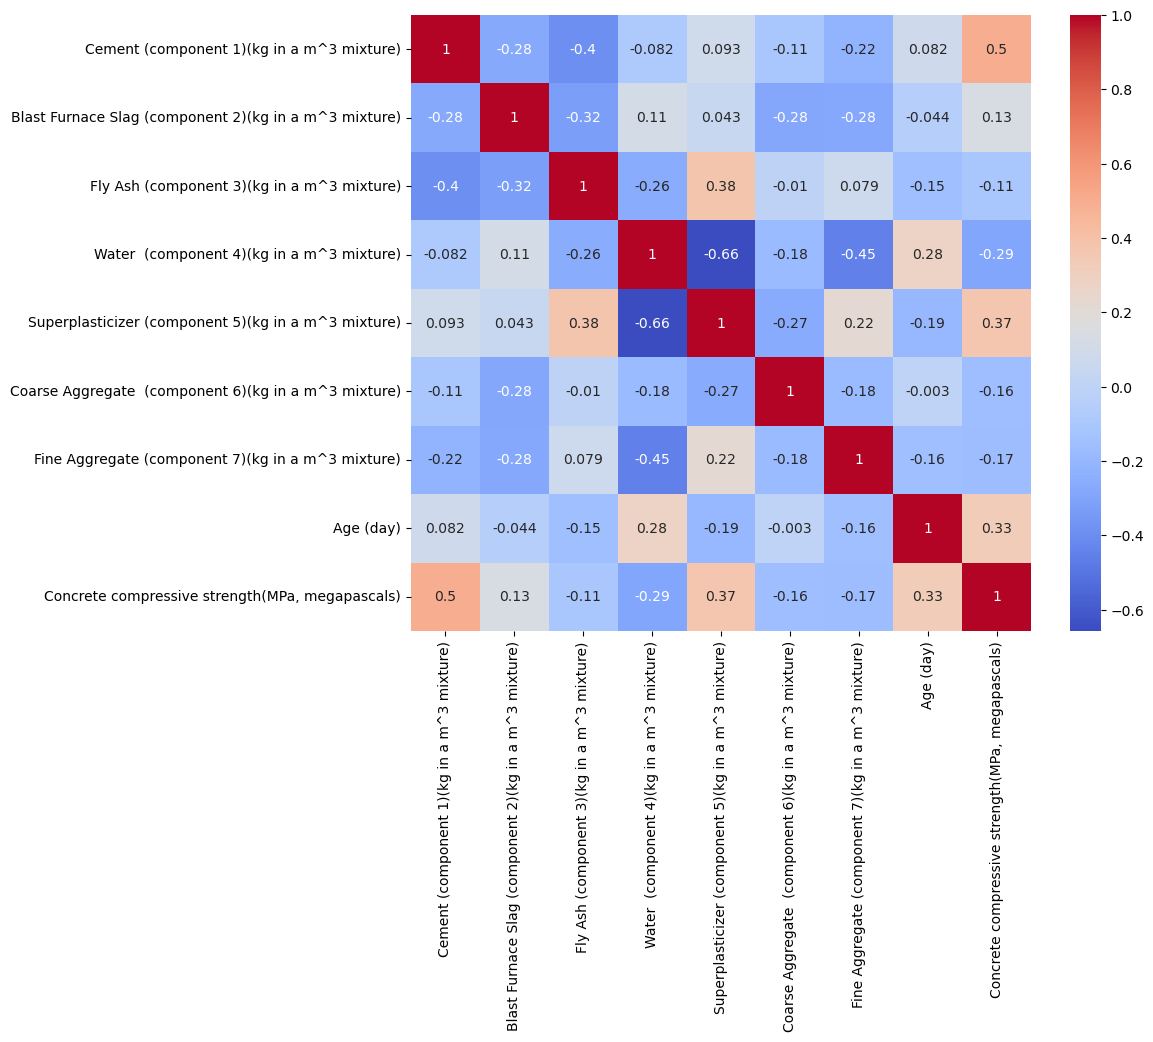

In [34]:
## Understanding relationship between variables
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

The correlation heatmap provides an overview of the linear relationships between the concrete mixture components, curing age, and concrete compressive strength. From the heatmap, cement content shows the strongest positive correlation with compressive strength (≈ 0.50), indicating that higher cement quantities generally contribute to higher strength. Age also exhibits a moderate positive correlation (≈ 0.33), which aligns with the well-known behavior of concrete gaining strength over time as hydration progresses. Superplasticizer content shows a moderate positive correlation (≈ 0.37) with strength, suggesting its role in improving workability and allowing better cement utilization without increasing water content.

In contrast, water content displays a noticeable negative correlation with compressive strength (≈ −0.29), supporting the understanding that excessive water weakens concrete due to higher porosity. Fine and coarse aggregates both show weak negative correlations with strength, implying that aggregate quantities alone are less influential compared to cement, water, and admixtures. Fly ash and blast furnace slag show relatively weak correlations with compressive strength, suggesting that their effects may be more complex or non-linear and potentially dependent on interactions with other components and curing age.

Additionally, the heatmap highlights strong correlations among some input variables themselves, such as the strong negative correlation between water and superplasticizer (≈ −0.66). This indicates multicollinearity, likely because superplasticizers are often used to reduce water demand while maintaining workability. Moderate correlations among cement, fly ash, and slag further suggest trade-offs in mixture design. Overall, this EDA indicates that cement, age, water, and superplasticizer are key factors influencing compressive strength, while also signaling the presence of multicollinearity that should be considered during model selection and interpretation.

# 3. Data Preparation

## 3.1 Data Cleaning

In [35]:
## Clean data
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"There are {duplicates} duplicate rows.")
else:
    print("No duplicate rows were found in the dataset.")

There are 25 duplicate rows.


The code above is used to check whether the dataset have any duplicate rows. It is seen that the dataset has total 25 duplicate rows. Since there are different ways to approach how to deal with duplicate data, it is important to consider the context of the dataset. Each row of the dataset represents a concrete mix experiment. If two rows are exactly the same across all features and the target, they do not add new information. In contrast, I would only keep duplicates if they represent intentional repeated experiments with different outcomes, or duplicates are necessary to determine how frequent that particular case can happen. This, however, is not the case here. Keeping them can bias the model by over-representing those exact conditions. So the correct approach here is to remove full duplicates.

In [36]:
df = df.drop_duplicates(keep='first')
print(f"Duplicate rows after cleaning: {df.duplicated().sum()}")

Duplicate rows after cleaning: 0


Now the duplicate rows are removed by just keeping the first one. It is then check to see if there are any more duplicate entries. Now it shows that there are no more duplicate rows.

In [37]:
df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals)'],
      dtype='object')

In [38]:
# Remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

For safety measure, the column names are cleaned up by removing extra whitespace at the beginning and end of each column name. It makes sure that column headers don’t accidentally have spaces that can mess up with my code. For example, if my column name was " Cement (component 1)(kg in a m^3 mixture) ", it will just become "Cement (component 1)(kg in a m^3 mixture)".

## 3.2 Train-Test Split

In [39]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

X = df.drop('Concrete compressive strength(MPa, megapascals)', axis=1)
y = df['Concrete compressive strength(MPa, megapascals)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


This code splits the dataset into training and testing sets in preparation for machine learning.
"X" is created by selecting all input features, while "y" contains the target variable, which is the concrete compressive strength. The "train_test_split" function from scikit-learn is then used to divide the data, with 80% allocated for training and 20% reserved for testing (test_size=0.2). The random_state=42 ensures that the split is reproducible, meaning the same train–test split is obtained each time the code is run. This separation allows the model to be trained on one portion of the data and evaluated on unseen data to assess its generalization performance.

# 4. Modelling

### 4.2 Train Model

In [40]:
## Initialise and train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Since I am trying to predict the compressive strength of concrete, it is a regressionproblem. Therefore, it is first trained with a linear regression model using scikit-learn. It first initializes the model with LinearRegression() and then fits it to the training data (X_train and y_train). After fitting, the model is ready to make predictions on new data. This will be our base model.

In [41]:
#Using random forest regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Next, I trained using another model "RandomForestRegressor" which uses random forest model for regression problems. It first initializes the model with 200 decision trees (n_estimators=200) and no maximum depth (max_depth=None), ensuring each tree can grow fully, while random_state=42 makes results reproducible. The model is then fitted to the training data (X_train and y_train).

# 5. Model Evaluation

In [47]:
## Evaluate model
from sklearn.metrics import mean_squared_error, r2_score

# Predict on test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Present results neatly
print("Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

Model Evaluation Metrics:
Mean Squared Error (MSE): 125.27
Root Mean Squared Error (RMSE): 11.19
R² Score: 0.580


These evaluation results indicate that the model’s performance is not very desirable. The RMSE of 11.19 MPa is relatively large compared to the average concrete compressive strength of around 36 MPa, meaning the model’s predictions often deviate substantially from the actual values. Additionally, the R² score of 0.58 shows that the model explains only about 58% of the variance in the target variable, leaving a significant portion of variation unexplained. This suggests that the model is underfitting the data and struggling to capture the complex relationships between the concrete mix features and compressive strength. Possible causes include the linear nature of the model, unscaled or skewed features, and the presence of nonlinear interactions that the model cannot account for.

In [48]:
#Evaluate random forest model

from sklearn.metrics import mean_squared_error, r2_score

# Predict on test set using Random Forest
y_pred_rf = rf.predict(X_test)

# Calculate metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Present results neatly
print("Random Forest Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.3f}")

Random Forest Model Evaluation Metrics:
Mean Squared Error (MSE): 26.25
Root Mean Squared Error (RMSE): 5.12
R² Score: 0.912


According to the evaluations, the Random Forest model predicts concrete compressive strength much more accurately than the Linear Regression model. The RMSE of 5.12 MPa is relatively small compared to the average strength of around 36 MPa, indicating that most predictions are very close to the actual values. The R² score of 0.912 shows that the model explains over 91% of the variance in the target, meaning it captures the relationships between the mix components and compressive strength very effectively.

The improved performance is likely due to Random Forest’s ability to handle nonlinear relationships and interactions between features, as well as its robustness to skewed or differently scaled variables. This makes it more suitable for this dataset, which has diverse feature ranges and nonlinear dependencies, resulting in more reliable and accurate predictions. I will choose this as my best model for now.

In [52]:
## New data
# New concrete mix sample
# Columns: Cement, Slag, Fly Ash, Water, Superplasticizer, Coarse Agg, Fine Agg, Age
X_new = [[300, 50, 20, 180, 5, 1000, 750, 28]]

# Convert to DataFrame
X_new_df = pd.DataFrame(X_new, columns=X_train.columns)

# Predict using Random Forest
y_pred_new_rf = rf.predict(X_new_df)

## Predict
print(f"Predicted Concrete Strength: {y_pred_new_rf[0]:.2f} MPa")


Predicted Concrete Strength: 38.82 MPa


## Iterative model development


In [45]:
## Further feature engineering / feature selection
df_dt_feat_impt = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

df_dt_feat_impt['Cumulative importance'] = df_dt_feat_impt['Importance'].cumsum()
df_dt_feat_impt

,Feature,Importance,Cumulative importance
7,Age (day),0.357703,0.357703
0,Cement (component 1)(kg in a m^3 mixture),0.306709,0.664412
3,Water (component 4)(kg in a m^3 mixture),0.088760,0.753172
4,Superplasticizer (component 5)(kg in a m^3 mix...,0.084158,0.837330
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.075413,0.912743
6,Fine Aggregate (component 7)(kg in a m^3 mixture),0.044119,0.956863
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,0.026844,0.983707
2,Fly Ash (component 3)(kg in a m^3 mixture),0.016293,1.000000


The feature importance analysis shows which input variables contribute most to predicting concrete compressive strength. Age (day) is the most influential feature, accounting for roughly 36% of the model’s decision-making, which aligns with engineering knowledge that concrete strength strongly depends on curing time. Cement content is the second most important feature (~31%), reflecting its key role as the primary binder in the mix. Together, age and cement account for nearly 66% of the predictive power.

Other features have smaller but still meaningful contributions: water (8.9%), superplasticizer (8.4%), and blast furnace slag (7.5%), which influence workability and strength. The aggregates (fine and coarse) and fly ash contribute less individually (less than 5% each), but collectively they still impact the model’s predictions.

The cumulative importance column shows that the first five features capture over 91% of the model’s predictive power, indicating that the model relies most heavily on age, cement, water, superplasticizer, and slag. This suggests that for tasks such as feature selection or dimensionality reduction, the less influential features could be candidates for removal without significantly reducing model performance.

In summary, the findings align well with engineering principles: curing time and cement content dominate strength outcomes, while water, admixtures, and supplementary materials fine-tune the results, and aggregates have a smaller, but still real, effect.

In [53]:
# Select only top important features
top_features = df_dt_feat_impt[df_dt_feat_impt['Cumulative importance'] <= 0.91]['Feature'].tolist()

# Prepare new training and test sets
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Train a new Random Forest
rf_top = RandomForestRegressor(n_estimators=200, random_state=42)
rf_top.fit(X_train_top, y_train)

# Evaluate
y_pred_top = rf_top.predict(X_test_top)
rmse_top = np.sqrt(mean_squared_error(y_test, y_pred_top))
r2_top = r2_score(y_test, y_pred_top)

print(f"RMSE: {rmse_top:.2f}, R²: {r2_top:.3f}")

RMSE: 6.48, R²: 0.859


In [54]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['auto', 'sqrt', 0.5, 0.75]
}

# Initialize Random Forest
rf = RandomForestRegressor(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,             # number of parameter settings sampled
    scoring='r2',          # use R² as scoring
    cv=5,                  # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1              # use all cores
)

# Fit to training data (use all features or top features)
random_search.fit(X_train, y_train)

# Best parameters and performance
best_params = random_search.best_params_
best_score = random_search.best_score_

print("Best Hyperparameters:", best_params)
print(f"Best CV R² Score: {best_score:.3f}")

# Predict on test set using best estimator
y_pred_best = random_search.best_estimator_.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print(f"Test Set RMSE: {rmse_best:.2f}, R²: {r2_best:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\GURU\anaconda3\envs\mldp\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
28 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\GURU\anaconda3\envs\mldp\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\GURU\anaconda3\envs\mldp\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\GURU\anaconda3\envs\mldp\Lib\site-packages\sklearn\base.py

Best Hyperparameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
Best CV R² Score: 0.890
Test Set RMSE: 5.11, R²: 0.912


To further improve the predictive performance of the Random Forest model, RandomizedSearchCV was used for hyperparameter tuning. The search explored 50 randomly selected combinations of key parameters, including the number of trees (n_estimators), maximum tree depth (max_depth), minimum samples per split and leaf (min_samples_split, min_samples_leaf), and the fraction of features considered at each split (max_features). During the process, a few combinations failed due to incompatible parameter settings, which is expected in a randomized search, but the majority of fits were successful.

The best configuration identified by the search included 400 trees, a maximum depth of 20, 50% of features considered per split, and minimal leaf and split constraints. This optimized model achieved a cross-validated R² of 0.890, indicating strong generalization across folds during training. When evaluated on the unseen test set, the model reached an R² of 0.912 with a Root Mean Squared Error (RMSE) of 5.11 MPa, demonstrating excellent predictive accuracy and stability.

These results show that the optimized Random Forest effectively captures the relationships between concrete mix components and compressive strength. By combining feature importance analysis and hyperparameter tuning, the model balances complexity and generalization: the most influential features (age, cement, water, superplasticizer, and slag) drive predictions, while the tuned parameters ensure the trees do not overfit or underfit the data. Overall, this approach provides a reliable framework for predicting the compressive strength of new concrete mixes, making it suitable for practical engineering applications.

## Conslusion

This project developed a machine learning model to predict the compressive strength of concrete based on mix components and curing age. By analyzing feature importance and optimizing a Random Forest model, the system can provide accurate predictions for new concrete mixes, with an R² of 0.912 and low RMSE. In the context of civil engineering, this has significant practical value: engineers can estimate concrete strength before performing physical tests, enabling faster mix design iterations and reducing reliance on time-consuming laboratory experiments. This approach can save time and resources during development and testing phases, improve decision-making in construction projects, and support more efficient material usage without compromising safety. Overall, the model demonstrates how AI can bridge data-driven insights and practical engineering applications, providing measurable benefits in project planning and quality control.

## Saving Model

In [56]:
import pickle

with open('random_forest_concrete.pkl', 'wb') as file:
    pickle.dump(random_search.best_estimator_, file)